In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [5]:
df=pd.read_csv("../data/Crop_recommendation.csv")

In [16]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [11]:
df.shape

(2200, 8)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [15]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [20]:
df[df["N"]==0]

,N,P,K,temperature,humidity,ph,rainfall,label
346,0,65,15,23.461683,23.221976,5.645436,95.842534,kidneybeans
382,0,55,22,22.986669,20.579406,5.916779,143.858494,kidneybeans
477,0,70,21,36.300497,56.030213,4.672437,101.607399,pigeonpeas
517,0,55,25,28.174894,43.667230,4.524172,45.781728,mothbeans
608,0,49,18,29.683617,87.935981,6.990095,41.824902,mungbean
829,0,65,24,28.495844,62.446162,7.841496,53.145310,lentil
875,0,69,21,25.869282,61.883211,7.072923,36.682840,lentil
878,0,74,17,23.333759,64.505158,7.240988,47.015107,lentil
891,0,67,22,29.821121,69.407321,6.593798,51.564611,lentil
904,0,27,38,22.445813,89.901470,6.738016,109.390600,pomegranate


In [24]:
df[df.duplicated()].sum()

N                0
P                0
K                0
temperature    0.0
humidity       0.0
ph             0.0
rainfall       0.0
label             
dtype: object

In [28]:
df["label"].unique()

<ArrowStringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

In [29]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

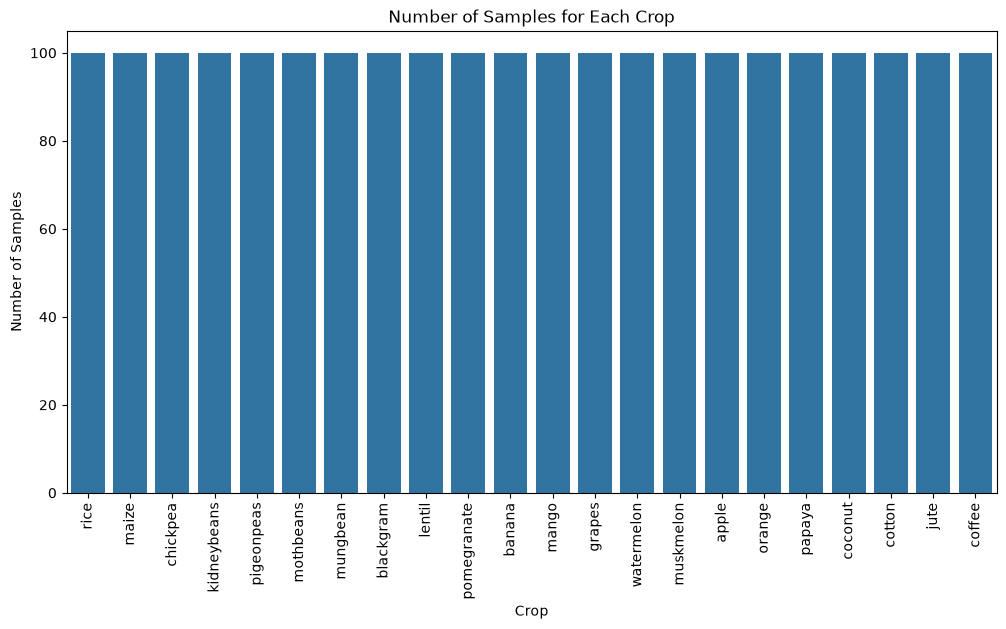

In [35]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Number of Samples for Each Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.show()

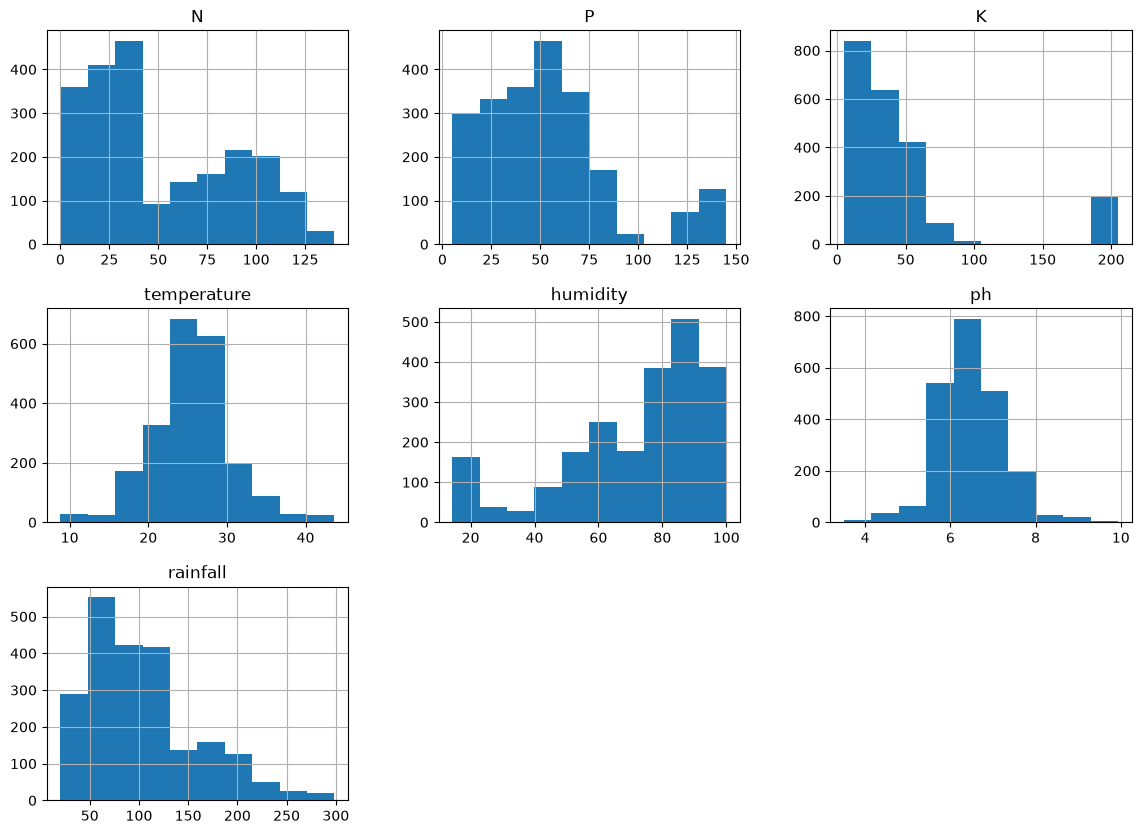

In [39]:
feature= ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
df[feature].hist(figsize=(14, 10))

plt.show()

<Axes: >

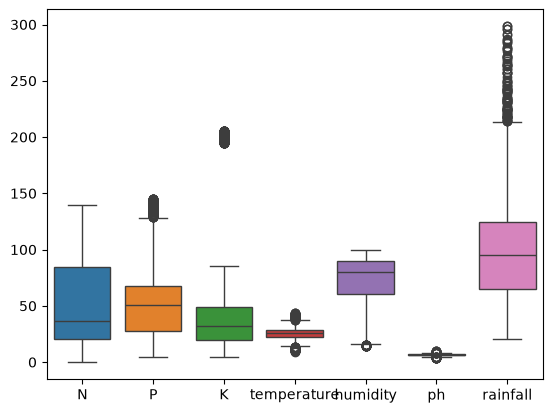

In [40]:
sns.boxplot(data=df[feature])

<Axes: >

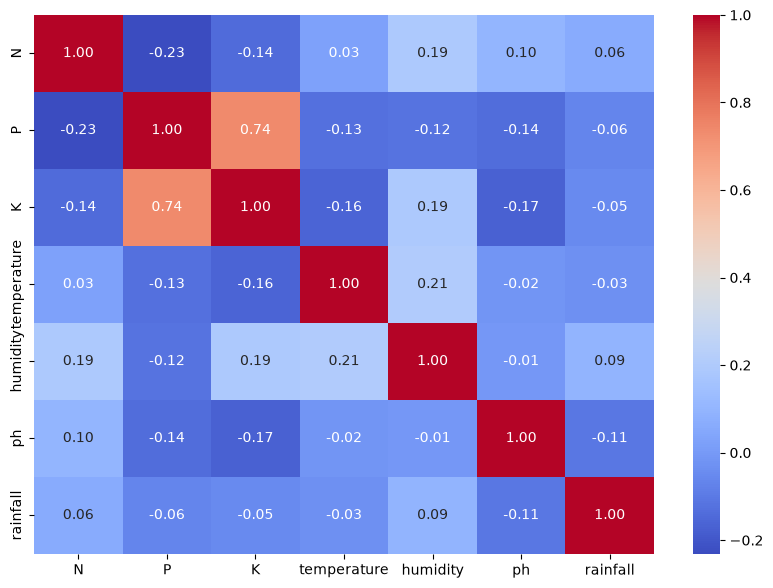

In [46]:
correlation = df[feature].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)


Observation: The correlation analysis shows that most agricultural features have weak linear correlations with each other. The strongest relationship is between phosphorus (P) and potassium (K), with a correlation of 0.74. However, both features are retained because they may provide useful information for crop classification. No feature is removed based solely on correlation analysis.

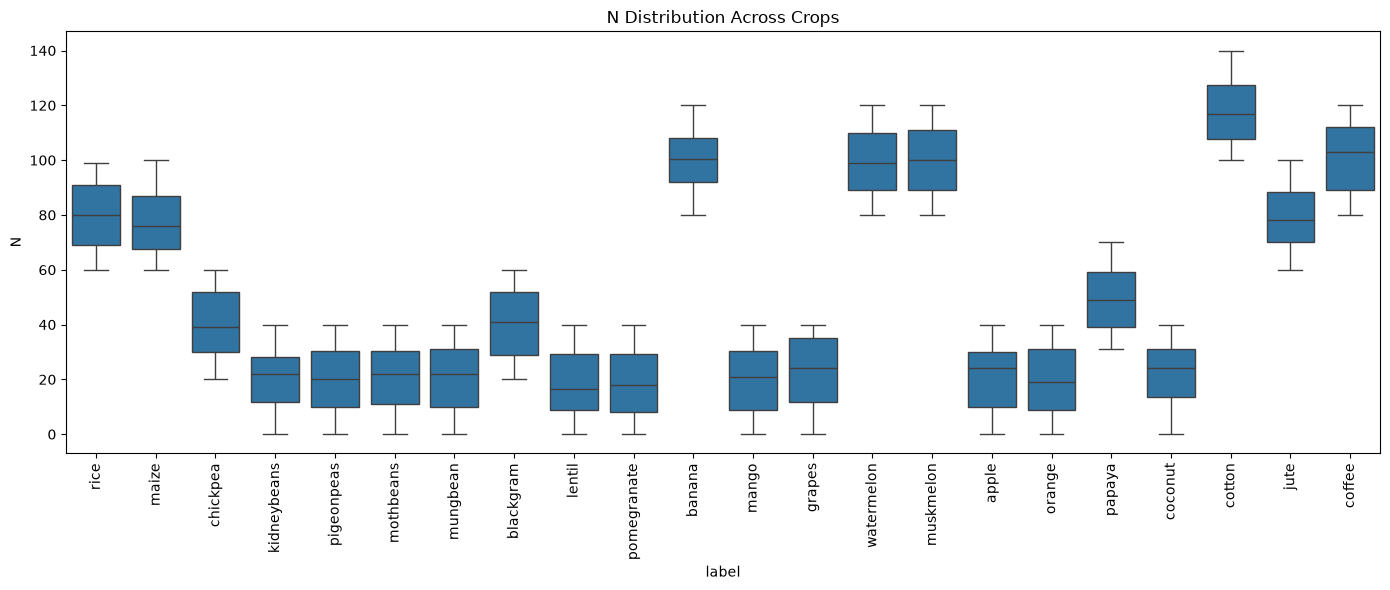

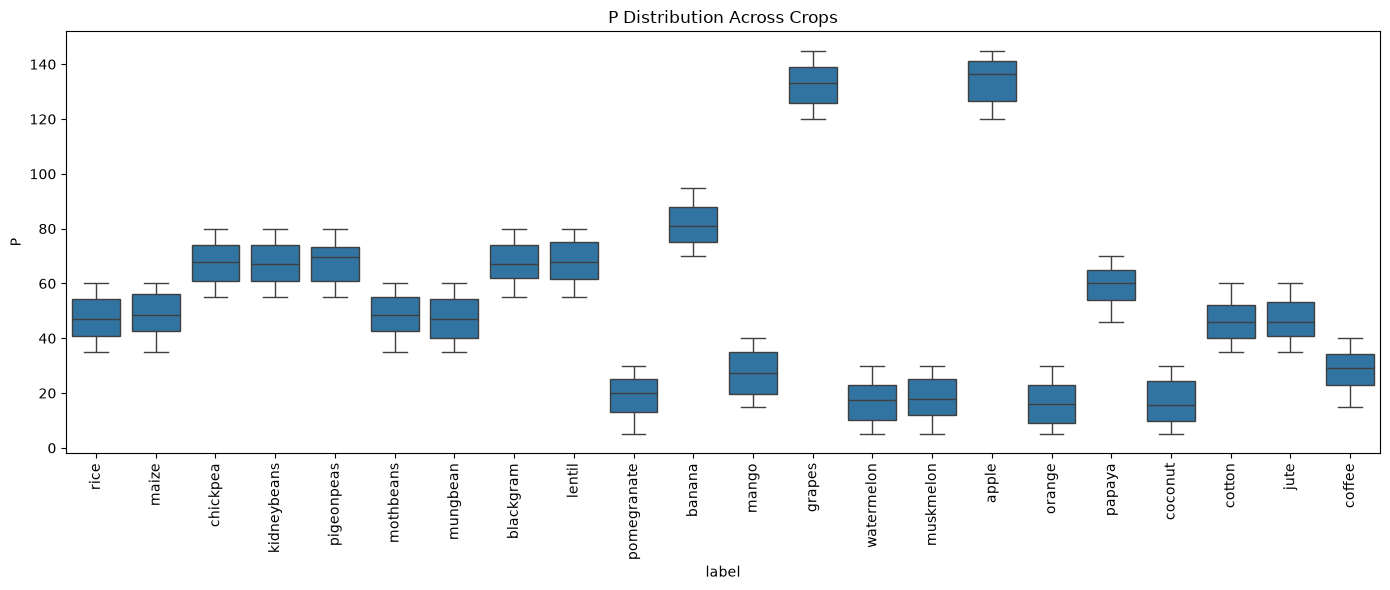

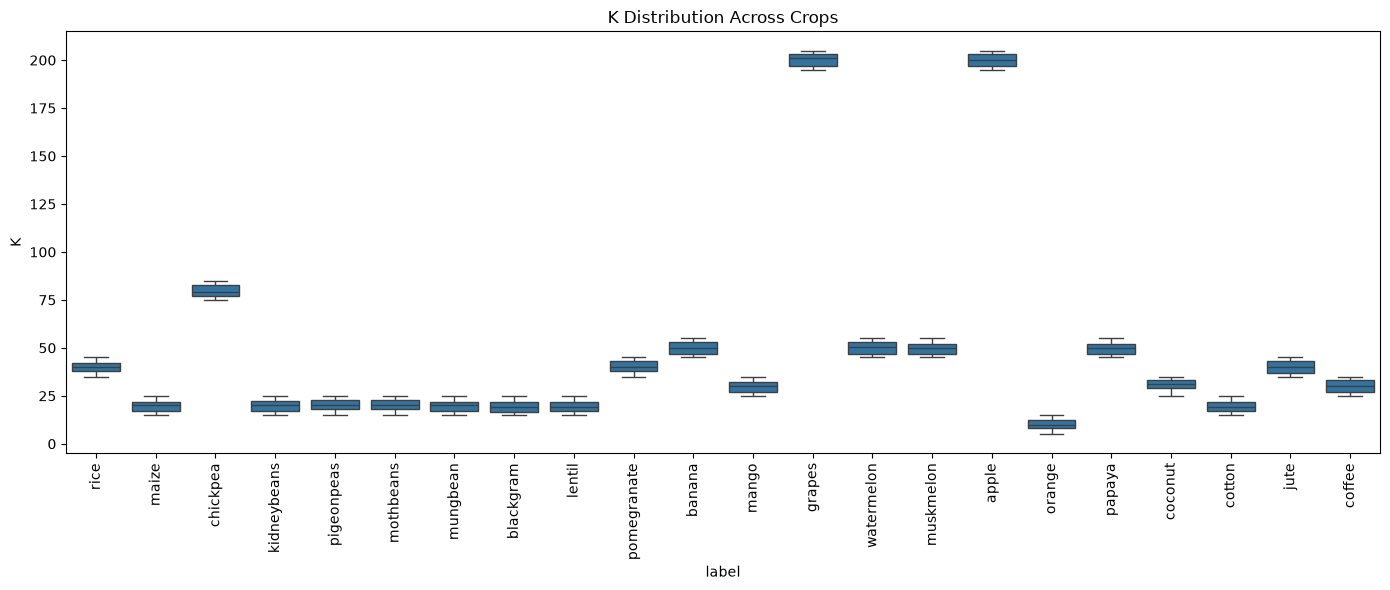

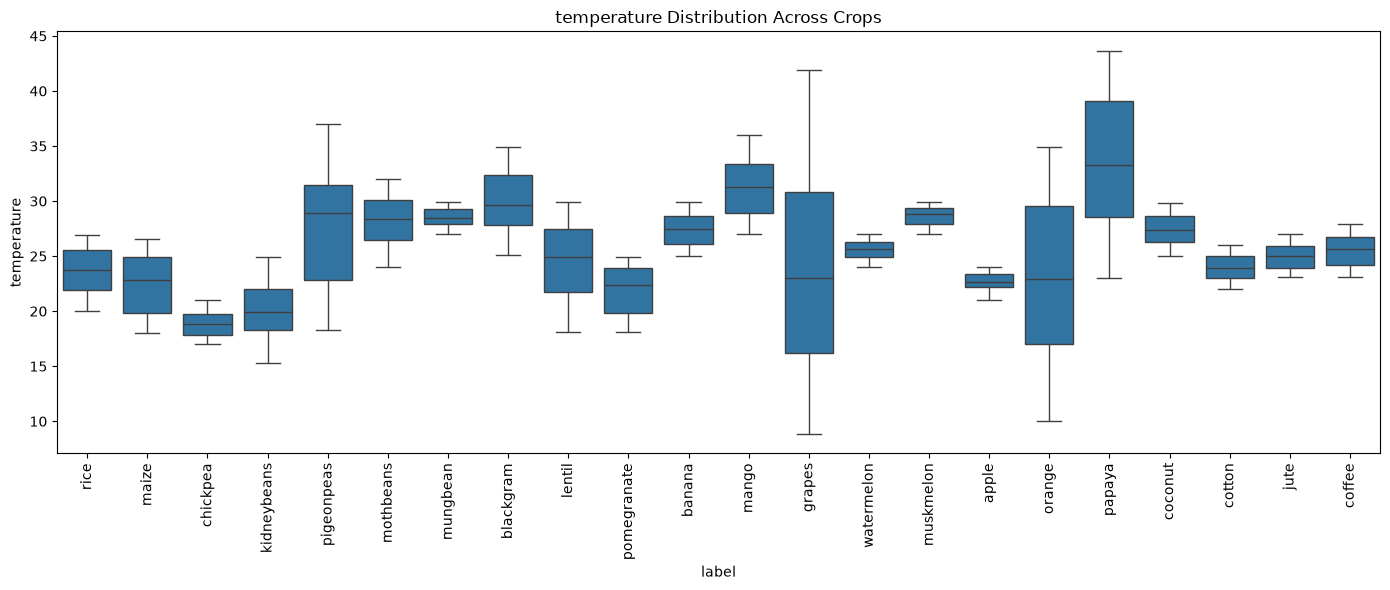

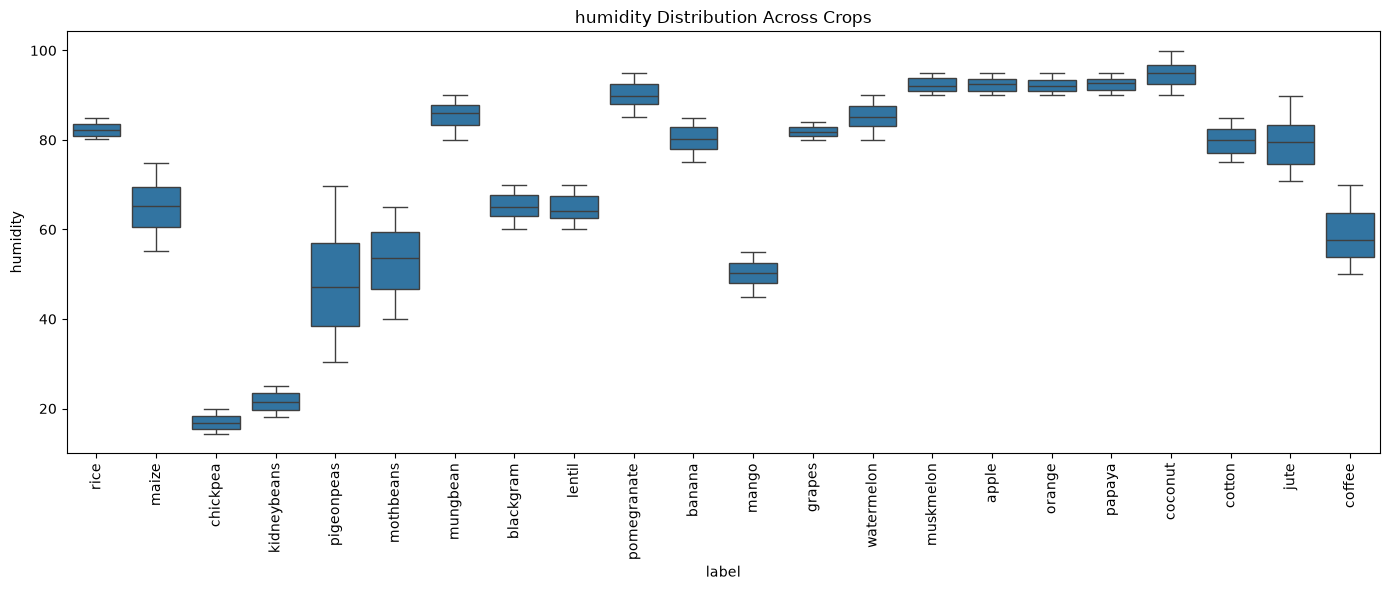

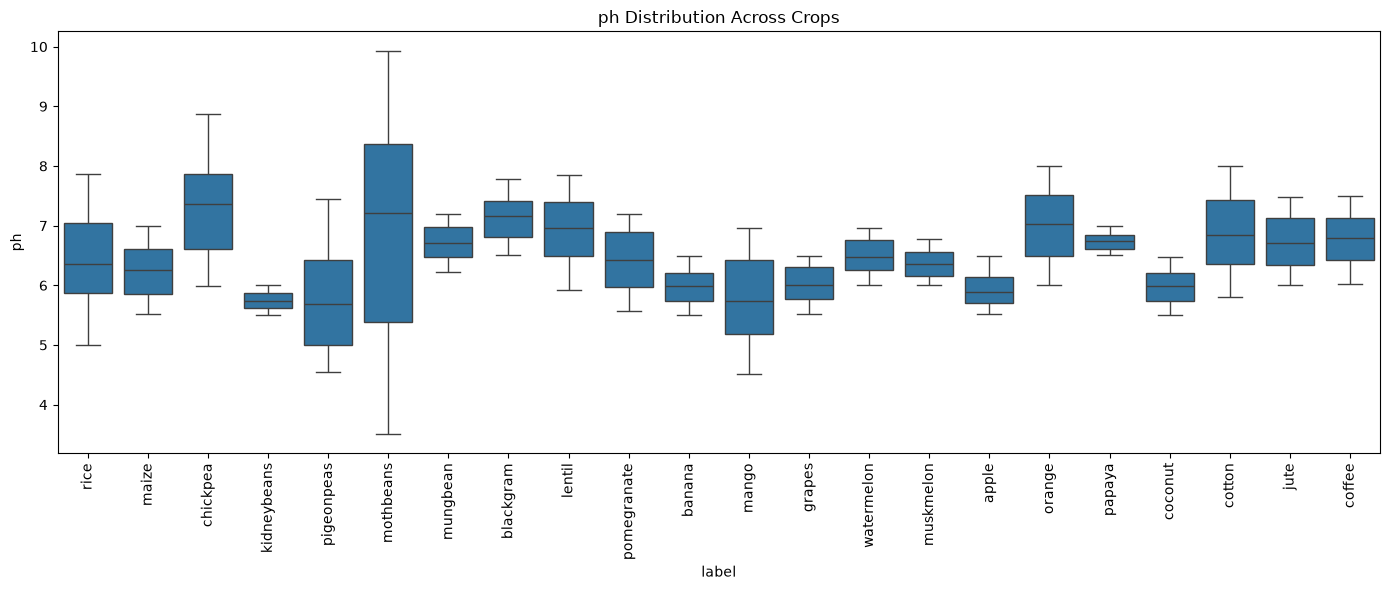

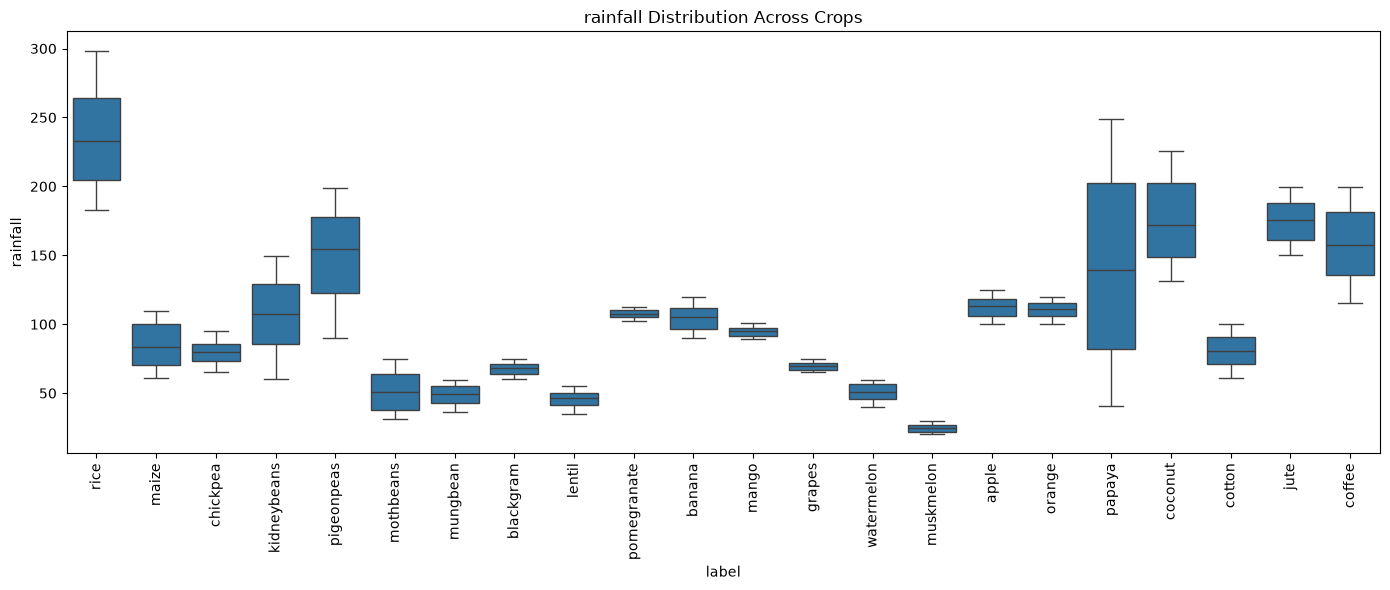

In [59]:
for feature in feature:
    plt.figure(figsize=(14, 6))
    
    sns.boxplot(
        data=df,
        x="label",
        y=feature
    )
    
    plt.xticks(rotation=90)
    plt.title(f"{feature} Distribution Across Crops")
    plt.tight_layout()
    plt.show()

Observation: The feature distributions across different crops show noticeable variations, which indicates that the agricultural features may help distinguish between crop classes. No major abnormal patterns or extreme outliers were observed that would require immediate removal.

Training data: (1760, 7)
Testing data: (440, 7)
